## Convert MRDH demand data (from activity-based model used in XCARCITY project) to MaaSSim input data

### Set-up

In [1]:
import pandas as pd
import osmnx as ox
import networkx as nx
import os
from link_demand_to_osm import *
from preprocess_utils import *

In [ ]:
# input parameters
study_area = "Delft"
year = 2025
month = 4
day = 1
min_trip_dist = 1000 # meter
sample_size = 50000 # before filtering in this case
closeness_bound = 200 # meter (origin and destination should be within this distance of the loaded network)

In [3]:
# Preprocess
date = {'year': year, 'month': month, 'day': day}
nw_type_extensions = {'drive': '', 'bike': '_bike', 'walk': '_walk'}
skim_available = {'drive': True, 'bike': True}
presaved_zones = False

### Sample the demand data
First, we download the data, compute some additional statistics and select trips (possibly based on a filter)

In [4]:
trips = pd.read_csv('50PercentTrips.csv', nrows=sample_size) #nrows=sample_size
pax = pd.read_csv('50PercentPersons.csv').sort_values(by='person_id').head(sample_size)
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y
0,5513,16,shopping,bike,9,22,82350.546875,458161.93750,87515.648438,457049.25000
1,11201,34,eatout,ebike,8,39,82362.250000,458146.87500,80806.382812,455101.43750
2,15353,46,shopping,ebike,9,5,82330.109375,458188.06250,81656.328125,455156.25000
3,24473,74,othdiscr,ebike,8,49,82410.195312,458051.03125,83403.460938,455115.00000
4,30489,92,work,bike,7,41,82330.109375,458188.06250,84138.812500,450752.40625
...,...,...,...,...,...,...,...,...,...,...
49995,81819193,249448,school,bike,7,39,77546.117188,450057.46875,80887.718750,454412.81250
49996,81819913,249450,work,car,7,42,77576.101562,450019.34375,76075.164062,438388.40625
49997,81820505,249452,school,bike,8,32,77552.054688,450049.93750,82061.593750,453970.78125
49998,81821177,249454,shopping,car,8,56,77428.343750,450080.75000,78904.492188,451482.31250


In [5]:
# Determine eucledian distance and filter based on distance, also filter adults
trips['eucledian_dist'] = trips.apply(lambda row: eucledian_distance(row['origin_coordinate_x'], row['origin_coordinate_y'], row['destination_coordinate_x'], row['destination_coordinate_y']), axis=1)
trips = trips[trips['eucledian_dist'] > min_trip_dist].copy()
pax = pax[pax['person_id'].isin(trips['person_id'])].copy()
pax = pax[pax['age'] >= 18].copy()
trips = trips[trips['person_id'].isin(pax['person_id'])].copy()
processed_demand = pd.DataFrame(index=trips.index)
processed_demand['person_id'] = trips['person_id'].copy()
processed_demand[['purpose', 'activity_mode_model']] = trips[['purpose', 'trip_mode']].copy()
trips

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y,eucledian_dist
0,5513,16,shopping,bike,9,22,82350.546875,458161.93750,87515.648438,457049.25000,5283.592303
1,11201,34,eatout,ebike,8,39,82362.250000,458146.87500,80806.382812,455101.43750,3419.855592
2,15353,46,shopping,ebike,9,5,82330.109375,458188.06250,81656.328125,455156.25000,3105.779807
3,24473,74,othdiscr,ebike,8,49,82410.195312,458051.03125,83403.460938,455115.00000,3099.492878
4,30489,92,work,bike,7,41,82330.109375,458188.06250,84138.812500,450752.40625,7652.476126
...,...,...,...,...,...,...,...,...,...,...,...
49993,81816961,249441,work,bike,8,26,77447.835938,450018.71875,81817.070312,447606.43750,4990.922746
49994,81818513,249446,othmaint,car,8,26,77558.257812,450042.06250,77096.648438,452513.18750,2513.869921
49996,81819913,249450,work,car,7,42,77576.101562,450019.34375,76075.164062,438388.40625,11727.383362
49998,81821177,249454,shopping,car,8,56,77428.343750,450080.75000,78904.492188,451482.31250,2035.532277


In [6]:
# Convert trip coordinates in RD New system to WGS84 coordinates and compute some general trip statistics
processed_demand['origin_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.origin_coordinate_x, row.origin_coordinate_y), axis=1)
processed_demand['dest_wgs84'] = trips.apply(lambda row: coordinate_conversion(row.destination_coordinate_x, row.destination_coordinate_y), axis=1)
processed_demand['eucl_dist'] = trips['eucledian_dist']
processed_demand['treq'] = trips.apply(lambda row: determine_treq(row, date=dict()), axis=1) # determine the required departure time for the trip

### Load network(s)
First, we load the network from OpenStreetMap and finding the corresponding OSM node for each request

In [7]:
# First, we download the network data (incl. skim matrices) for each type (drive, bike, walk), which has already been downloaded from OSM and saved
network_types = determine_preprocessed_network_types(study_area, nw_type_extensions)
graphs=dict()
filtered_rows = None
for network_type in network_types:
    skim_type = skim_available[network_type]
    print(f"Loading {network_type} network data")
    extension = nw_type_extensions[network_type]
    G, skims = load_fleetpy_network(study_area, network_type, return_skim=skim_type, presaved_zones=presaved_zones)
    # df = pd.DataFrame()

    # 1. Extract coordinates as numpy arrays
    x_origins = processed_demand['origin_wgs84'].apply(lambda x: x[1]).to_numpy()
    y_origins = processed_demand['origin_wgs84'].apply(lambda x: x[0]).to_numpy()
    x_dest = processed_demand['dest_wgs84'].apply(lambda x: x[1]).to_numpy()
    y_dest = processed_demand['dest_wgs84'].apply(lambda x: x[0]).to_numpy()

    # 2. Use osmnx's vectorized nearest_nodes (fast!)
    origin_ids = ox.distance.nearest_nodes(G, X=x_origins, Y=y_origins, return_dist=True)
    dest_ids = ox.distance.nearest_nodes(G, X=x_dest, Y=y_dest, return_dist=True)

    # 3. Create new DataFrame
    df = pd.DataFrame({
        f'origin_id{extension}': origin_ids[0],
        f'destination_id{extension}': dest_ids[0],
        f'dist_to_orig_node{extension}': origin_ids[1],
        f'dist_to_dest_node{extension}': dest_ids[1],
    }, index=processed_demand.index)

    # 4. Filter out trips that are too far from the network (i.e. with origin and/or destination further than the closeness bound)
    if filtered_rows is None:
        filtered_rows = df[(df[f'dist_to_orig_node{extension}'] < closeness_bound) | (df[f'dist_to_dest_node{extension}'] < closeness_bound)].index
        processed_demand = processed_demand.loc[filtered_rows].copy()
        pax = pax.loc[pax['person_id'].isin(processed_demand['person_id'])].copy()
    df = df.loc[filtered_rows].copy()

    # 5. Travel times and distances
    if skims is not None:
        origin_ids = np.asarray(df[f'origin_id{extension}'], dtype=int)
        dest_ids = np.asarray(df[f'destination_id{extension}'], dtype=int)
        tt_vals = skims['tt'][origin_ids, dest_ids]
        dist_vals = skims['distance'][origin_ids, dest_ids]
        df[f'ttrav{extension}'] = tt_vals
        df[f'dist{extension}'] = dist_vals
    else:
        # fallback with loop only if necessary
        df[f'ttrav{extension}'] = [
            nx.shortest_path_length(G, o, d, weight="travel_time")
            for o, d in zip(origin_ids, dest_ids)
        ]

    # 6. Concatenate back to main df
    processed_demand = pd.concat([processed_demand, df], axis=1)
    graphs[network_type] = G.copy()
    
skims = None # remove from memory
G = None

Loading drive network data
Loading bike network data


In [8]:
df
# filtered_rows

,origin_id_bike,destination_id_bike,dist_to_orig_node_bike,dist_to_dest_node_bike,ttrav_bike,dist_bike
129,1685,2363,8954.708029,79.672053,1160.52228,6447.346
137,1685,2282,8932.286602,12.102876,965.57166,5364.287
172,1685,2363,8984.641533,79.672053,1160.52228,6447.346
261,1685,801,8884.497366,79.493918,932.35536,5179.752
321,1685,1439,8800.742929,81.321872,792.50148,4402.786
...,...,...,...,...,...,...
49943,2410,1104,5296.989532,30.409351,258.83082,1437.949
49947,1991,1125,44.302346,43.887713,496.06398,2755.911
49976,2410,401,5181.095751,74.254801,777.92112,4321.784
49980,2410,454,5169.750225,82.564929,1130.32404,6279.578


In [9]:
processed_demand

,person_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,dist_to_orig_node,dist_to_dest_node,ttrav,dist,origin_id_bike,destination_id_bike,dist_to_orig_node_bike,dist_to_dest_node_bike,ttrav_bike,dist_bike
129,1211,work,bike,"(52.10520662067803, 4.322897445621018)","(51.99803219562168, 4.33928138587289)",11977.291646,2025-04-01 07:20:18,1685,2363,8954.708029,79.672053,390.157787,6447.346,1685,2363,8954.708029,79.672053,1160.52228,6447.346
137,1243,work,car,"(52.104746354815084, 4.321760587660719)","(52.00587135540939, 4.35614728156266)",11251.028652,2025-04-01 07:52:38,1685,2282,8932.286602,12.102876,323.832899,5364.287,1685,2282,8932.286602,12.102876,965.57166,5364.287
172,1460,work,car,"(52.104939215213435, 4.32038133993856)","(51.99803219562168, 4.33928138587289)",11965.140988,2025-04-01 08:42:59,1685,2363,8984.641533,79.672053,390.157787,6447.346,1685,2363,8984.641533,79.672053,1160.52228,6447.346
261,1913,work,ebike,"(52.10378854875116, 4.319561956496848)","(52.01130265650527, 4.359018861600354)",10640.074164,2025-04-01 07:37:22,1685,801,8884.497366,79.493918,330.146651,5179.752,1685,801,8884.497366,79.493918,932.35536,5179.752
321,2299,social,car,"(52.10298006028657, 4.319554354908223)","(52.00859828062869, 4.363221105854128)",10919.873441,2025-04-01 08:19:19,1685,1439,8800.742929,81.321872,242.949467,4402.786,1685,1439,8800.742929,81.321872,792.50148,4402.786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49943,249134,work,ebike,"(52.0340015391423, 4.256971343931821)","(52.01388644194026, 4.343009403779524)",6315.313416,2025-04-01 08:39:34,2410,1104,5296.989532,30.409351,121.063872,1440.974,2410,1104,5296.989532,30.409351,258.83082,1437.949
49947,249153,atwork,cp,"(51.99656024418774, 4.353025927169279)","(52.014043106345454, 4.343887661449511)",2043.869653,2025-04-01 08:28:05,1991,1125,44.302346,43.887713,220.134984,2755.911,1991,1125,44.302346,43.887713,496.06398,2755.911
49976,249349,work,car,"(52.03275066435045, 4.257847622494269)","(51.99516031071649, 4.3612488999935755)",8239.241522,2025-04-01 08:47:01,2410,401,5181.095751,74.254801,319.685959,4387.282,2410,401,5181.095751,74.254801,777.92112,4321.784
49980,249369,work,bike,"(52.03304657625348, 4.258270434136448)","(51.9980092492275, 4.385844080894442)",9586.404608,2025-04-01 07:30:42,2410,454,5169.750225,82.564929,418.415908,7143.159,2410,454,5169.750225,82.564929,1130.32404,6279.578


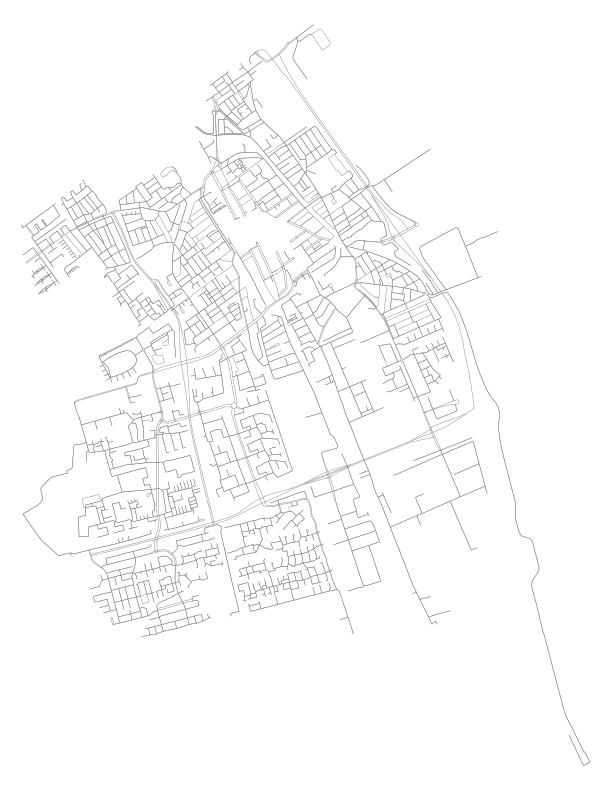

In [10]:
# Plot network
_ = ox.plot_graph(graphs['drive'], figsize=(10, 10), node_size=0, edge_linewidth=0.3,
                            show=False, close=False,
                            edge_color='grey', bgcolor='white')

Below, we establish passenger (not trip) data

In [11]:
passengers = pax[['person_id', 'urbanized', 'driving_license', 'age', 'value_of_time']].copy()
passengers['sex'] = pax.apply(lambda row: "Male" if row.sex == 1 else "Female", axis=1)
passengers['bike_option'] = pax.apply(lambda row: True if row.has_bike + row.has_ebike > 0 else False, axis=1)
passengers['car_option'] = pax.apply(lambda row: True if row.has_car > 0 and row.driving_license > 0 else False, axis=1)
passengers = passengers.rename(columns={'value_of_time': 'VoT'})


### Save demand dataframes (requests and passengers)

In [12]:
# Output path
output_path = "output"

In [13]:
# Save person characterstics to csv
passengers = passengers[passengers['person_id'].isin(processed_demand['person_id'])]  # only keep id's of people who make a (filtered) trip (double check)
passengers = passengers.rename(columns={'person_id': 'pax_id'})
passengers.to_csv(os.path.join(output_path,'passengers.csv'), index=False)
passengers

,pax_id,urbanized,driving_license,age,VoT,sex,bike_option,car_option
49266,1211,4,1,37,13.535661,Male,True,False
446732,1243,4,1,64,24.476197,Female,True,True
248682,1460,4,1,55,2.885723,Male,True,True
298309,1913,4,1,45,16.020706,Male,True,True
446754,2299,4,1,73,7.443023,Male,True,True
...,...,...,...,...,...,...,...,...
352820,249134,4,0,20,5.571919,Female,True,False
352822,249153,4,1,45,3.146248,Female,True,True
253738,249349,4,1,34,18.585349,Male,True,True
153965,249369,4,1,37,10.097390,Male,True,True


In [14]:
processed_demand = processed_demand.rename(columns={'person_id': 'pax_id'})
processed_demand.to_csv(os.path.join(output_path,'requests.csv'), index=False)
processed_demand

,pax_id,purpose,activity_mode_model,origin_wgs84,dest_wgs84,eucl_dist,treq,origin_id,destination_id,dist_to_orig_node,dist_to_dest_node,ttrav,dist,origin_id_bike,destination_id_bike,dist_to_orig_node_bike,dist_to_dest_node_bike,ttrav_bike,dist_bike
129,1211,work,bike,"(52.10520662067803, 4.322897445621018)","(51.99803219562168, 4.33928138587289)",11977.291646,2025-04-01 07:20:18,1685,2363,8954.708029,79.672053,390.157787,6447.346,1685,2363,8954.708029,79.672053,1160.52228,6447.346
137,1243,work,car,"(52.104746354815084, 4.321760587660719)","(52.00587135540939, 4.35614728156266)",11251.028652,2025-04-01 07:52:38,1685,2282,8932.286602,12.102876,323.832899,5364.287,1685,2282,8932.286602,12.102876,965.57166,5364.287
172,1460,work,car,"(52.104939215213435, 4.32038133993856)","(51.99803219562168, 4.33928138587289)",11965.140988,2025-04-01 08:42:59,1685,2363,8984.641533,79.672053,390.157787,6447.346,1685,2363,8984.641533,79.672053,1160.52228,6447.346
261,1913,work,ebike,"(52.10378854875116, 4.319561956496848)","(52.01130265650527, 4.359018861600354)",10640.074164,2025-04-01 07:37:22,1685,801,8884.497366,79.493918,330.146651,5179.752,1685,801,8884.497366,79.493918,932.35536,5179.752
321,2299,social,car,"(52.10298006028657, 4.319554354908223)","(52.00859828062869, 4.363221105854128)",10919.873441,2025-04-01 08:19:19,1685,1439,8800.742929,81.321872,242.949467,4402.786,1685,1439,8800.742929,81.321872,792.50148,4402.786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49943,249134,work,ebike,"(52.0340015391423, 4.256971343931821)","(52.01388644194026, 4.343009403779524)",6315.313416,2025-04-01 08:39:34,2410,1104,5296.989532,30.409351,121.063872,1440.974,2410,1104,5296.989532,30.409351,258.83082,1437.949
49947,249153,atwork,cp,"(51.99656024418774, 4.353025927169279)","(52.014043106345454, 4.343887661449511)",2043.869653,2025-04-01 08:28:05,1991,1125,44.302346,43.887713,220.134984,2755.911,1991,1125,44.302346,43.887713,496.06398,2755.911
49976,249349,work,car,"(52.03275066435045, 4.257847622494269)","(51.99516031071649, 4.3612488999935755)",8239.241522,2025-04-01 08:47:01,2410,401,5181.095751,74.254801,319.685959,4387.282,2410,401,5181.095751,74.254801,777.92112,4321.784
49980,249369,work,bike,"(52.03304657625348, 4.258270434136448)","(51.9980092492275, 4.385844080894442)",9586.404608,2025-04-01 07:30:42,2410,454,5169.750225,82.564929,418.415908,7143.159,2410,454,5169.750225,82.564929,1130.32404,6279.578


In [15]:
pax

,person_id,household_id,age,PNUM,sex,pemploy,pstudent,ptype,driving_license,education,...,num_joint_tours,non_mandatory_tour_frequency,num_non_mand,num_escort_tours,num_eatout_tours,num_shop_tours,num_maint_tours,num_discr_tours,num_social_tours,num_non_escort_tours
49266,1211,854,37,1,1,1,3,1,1,2,...,0,0,0,0,0,0,0,0,0,0
446732,1243,872,64,3,2,1,3,1,1,3,...,0,0,0,0,0,0,0,0,0,0
248682,1460,1008,55,3,1,1,3,1,1,3,...,0,0,0,0,0,0,0,0,0,0
298309,1913,1249,45,1,1,1,3,1,1,4,...,1,0,0,0,0,0,0,0,1,0
446754,2299,1442,73,2,1,3,3,5,1,4,...,0,11,3,0,0,0,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352820,249134,128796,20,3,2,2,2,3,0,3,...,0,0,0,0,0,0,0,0,0,0
352822,249153,128806,45,3,2,1,3,1,1,4,...,0,0,0,0,0,0,0,0,0,0
253738,249349,128884,34,2,1,1,3,1,1,4,...,0,0,0,0,0,0,0,0,0,0
153965,249369,128892,37,3,1,1,3,1,1,3,...,0,0,0,0,0,0,0,0,0,0


Origin: 1620, destination: 1408


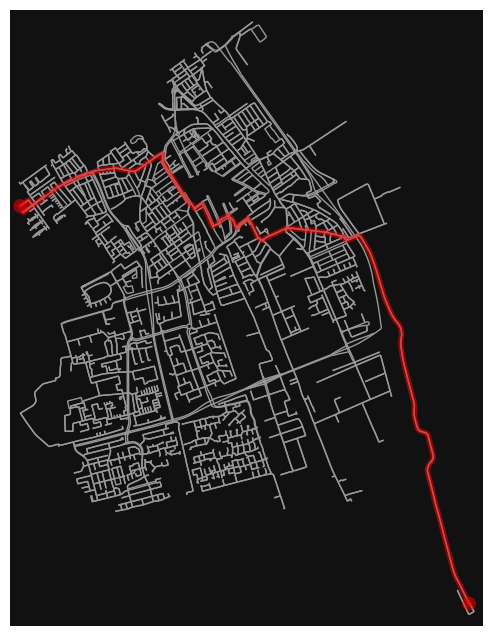

In [16]:
# plot the route of the longest trip
longest_trip = processed_demand.loc[processed_demand["dist"].idxmax(), ["origin_id", "destination_id"]]
origin = longest_trip['origin_id']
destination = longest_trip['destination_id']
print('Origin: {}, destination: {}'.format(origin, destination))
route = nx.shortest_path(graphs["drive"], origin, destination, weight='length')
fig, ax = ox.plot_graph_route(graphs['drive'], route, node_size=0)

In [17]:
processed_demand['dist'].describe()

count     1847.000000
mean      4714.492153
std       1840.357459
min          0.000000
25%       3532.237000
50%       4755.599000
75%       5950.649500
max      10558.283000
Name: dist, dtype: float64

In [18]:
# Remove request with infinite travel time (should already be removed in network generation process, i.e. only accessible nodes should be possible as origin/destination)
# processed_demand = processed_demand.loc[processed_demand['dist'] != np.inf]

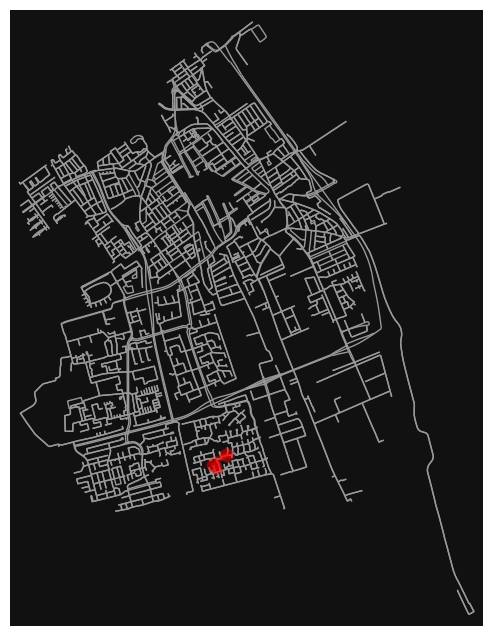

In [21]:
origin = 12
dest = 102
route = nx.shortest_path(graphs['drive'], origin, dest, weight='length')
fig, ax = ox.plot_graph_route(graphs['drive'], route, node_size=0)

In [22]:
trips.loc[trips['eucledian_dist'] > 30000]

,trip_id,person_id,purpose,trip_mode,exact_depart_hour,exact_depart_minute,origin_coordinate_x,origin_coordinate_y,destination_coordinate_x,destination_coordinate_y,eucledian_dist
620,1293921,3944,social,car,9,26,81541.453125,457413.031250,69341.000000,427511.000000,32295.240041
2624,4699897,14328,work,car,7,48,79786.406250,458809.000000,83231.859375,428654.562500,30350.638349
4142,7477401,22796,work,car,7,30,79180.078125,458494.750000,96319.273438,432722.656250,30950.813111
4346,7817537,23833,work,car,8,17,79017.179688,458567.812500,99103.406250,435951.000000,30248.581871
4388,7896801,24075,othdiscr,car,7,45,78838.867188,458399.312500,94758.812500,429381.562500,33097.952713
4555,8211793,25035,work,car,7,23,78860.031250,458266.343750,97613.007812,432314.312500,32018.464297
8161,14479217,44143,work,car,7,23,84826.929688,457279.843750,69570.524946,428762.039371,32342.279639
15985,27355513,83400,work,cp,7,13,82690.312500,455881.468750,98031.984375,430028.468750,30062.343637
19912,33372017,101743,work,pt,7,41,82545.831294,454515.903930,67589.000000,428462.000000,30041.849349
20728,34665649,105687,work,car,7,29,81854.492188,454472.406250,102669.218750,430877.718750,31463.663488


In [23]:
# Script to convert requests into georequests which can be used to generate PT itineraries with OpenTripPlanner (query_PT repo)
georequests = pd.DataFrame(index=processed_demand.index)
georequests['pax_id'] = processed_demand['pax_id'].copy()
georequests['treq'] = processed_demand['treq'].copy()
georequests['origin_x'] = processed_demand['origin_wgs84'].apply(lambda row: row[1])
georequests['origin_y'] = processed_demand['origin_wgs84'].apply(lambda row: row[0])
georequests['destination_x'] = processed_demand['dest_wgs84'].apply(lambda row: row[1])
georequests['destination_y'] = processed_demand['dest_wgs84'].apply(lambda row: row[0])
georequests.to_csv(os.path.join(output_path,'georequests.csv'), index=False)

In [24]:
georequests

,pax_id,treq,origin_x,origin_y,destination_x,destination_y
129,1211,2025-04-01 07:20:18,4.322897,52.105207,4.339281,51.998032
137,1243,2025-04-01 07:52:38,4.321761,52.104746,4.356147,52.005871
172,1460,2025-04-01 08:42:59,4.320381,52.104939,4.339281,51.998032
261,1913,2025-04-01 07:37:22,4.319562,52.103789,4.359019,52.011303
321,2299,2025-04-01 08:19:19,4.319554,52.102980,4.363221,52.008598
...,...,...,...,...,...,...
49943,249134,2025-04-01 08:39:34,4.256971,52.034002,4.343009,52.013886
49947,249153,2025-04-01 08:28:05,4.353026,51.996560,4.343888,52.014043
49976,249349,2025-04-01 08:47:01,4.257848,52.032751,4.361249,51.995160
49980,249369,2025-04-01 07:30:42,4.258270,52.033047,4.385844,51.998009
